In [ ]:
import shap
print(shap.__version__)

0.51.0


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(
    r"C:\Users\moham\ALFIDO_TECH\TASK1-Classification\dataset\ChurnDataset.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#datacleaning
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [5]:
#encoding
categorical_cols = df.select_dtypes(
    include=['object', 'string']
).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(
        df[col].astype(str)
    )

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [6]:
#trainingmodel
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [7]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
5,PhoneService,1.020357
14,Contract,0.721993
15,PaperlessBilling,0.356723
8,OnlineSecurity,0.293026
11,TechSupport,0.256804
7,InternetService,0.227226
3,Dependents,0.184115
1,SeniorCitizen,0.178126
9,OnlineBackup,0.153567
10,DeviceProtection,0.082099


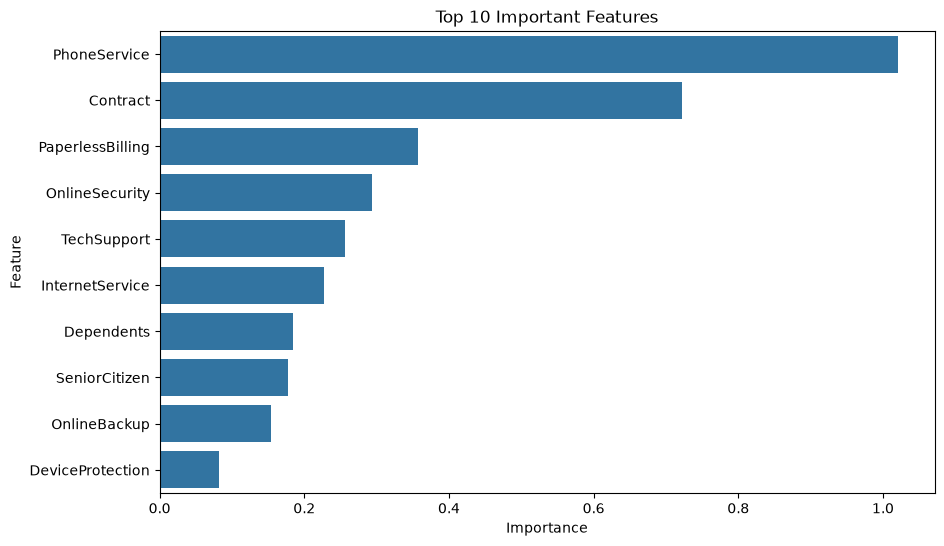

In [9]:
#plotfeatureimportance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

In [10]:
#SHAP explainability
explainer = shap.LinearExplainer(
    model,
    X_train
)

shap_values = explainer.shap_values(
    X_test
)

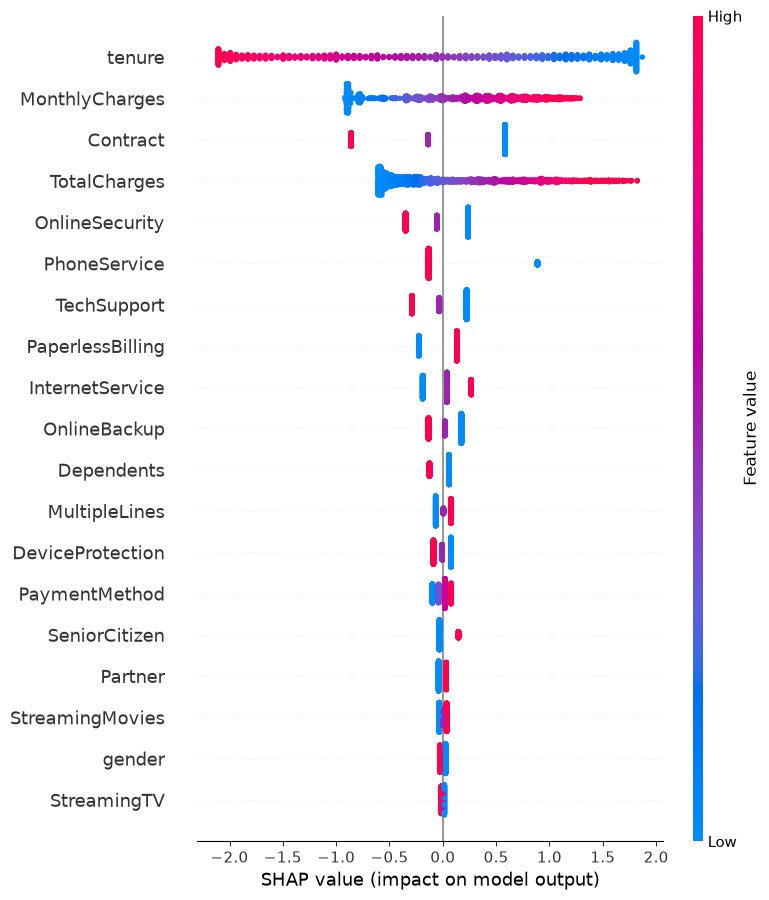

In [12]:
#SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test
)

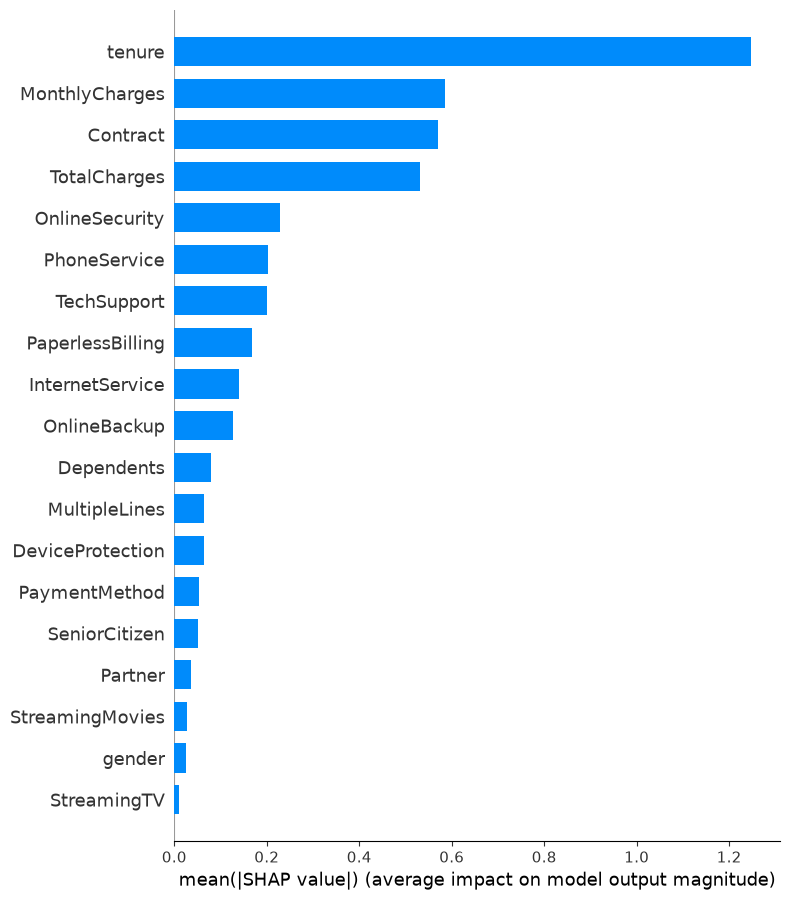

In [13]:
#SHAP BAR PLOT
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [16]:
#fairness analysis by gender
gender_bias = df.groupby('gender')['Churn'].mean()

print(gender_bias)

gender
0    0.269209
1    0.261603
Name: Churn, dtype: float64


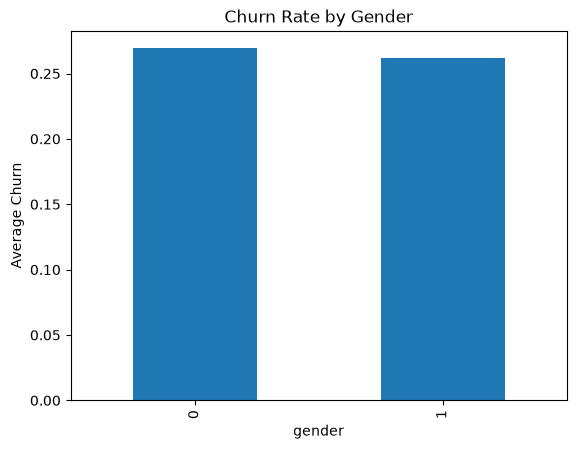

In [17]:
#plotting..
gender_bias.plot(kind='bar')

plt.title('Churn Rate by Gender')
plt.ylabel('Average Churn')

plt.show()

In [18]:
#fairness analysis bysenior citizen
senior_bias = df.groupby(
    'SeniorCitizen'
)['Churn'].mean()

print(senior_bias)

SeniorCitizen
0    0.236062
1    0.416813
Name: Churn, dtype: float64


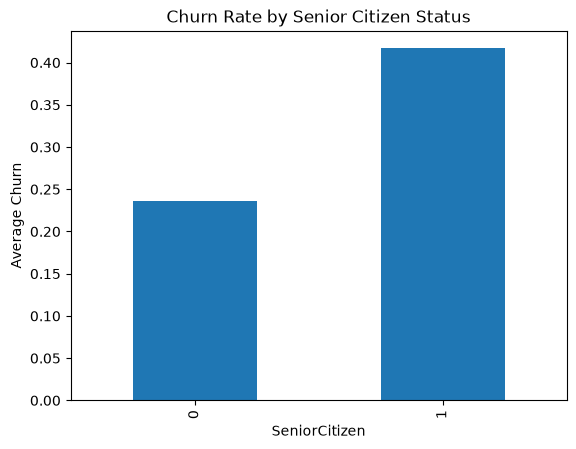

In [19]:
senior_bias.plot(kind='bar')

plt.title(
    'Churn Rate by Senior Citizen Status'
)

plt.ylabel('Average Churn')

plt.show()

In [ ]:
## Bias Mitigation Recommendations

1. Monitor model predictions across demographic groups regularly.
2. Ensure balanced representation of customer groups during model training.
3. Evaluate fairness metrics before deployment.
4. Retrain the model periodically using updated customer data.
5. Use explainability tools such as SHAP to understand prediction behavior.